# Valuation Engine Prototype

This notebook serves as the experimental environment for the updated `ValuationEngine`. It demonstrates the dynamic architecture, which adapts to any feature set and uses Optuna for automated hyperparameter optimization.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.model_selection import train_test_split

# Enable autoreload to pick up changes in src/valuation.py
%load_ext autoreload
%autoreload 2

# Add src to path
sys.path.append(os.path.abspath("../src"))
from valuation import ValuationEngine

%matplotlib inline
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading
We load the finalized ML-ready dataset: `UNIVERSAL_embedded.parquet`. This dataset contains all financial features, categorical sectors, and 384-dimensional NLP embeddings.

### Smart Mid-Market Focus
To improve valuation precision, the pipeline now implements a **Smart Mid-Market Filter** at the Gold Layer. This removes extreme outliers that often follow non-standard valuation physics:
*   **Small-Cap Outliers:** Removed companies with Enterprise Value < **$100M** (high noise/option-value bias).
*   **Mega-Cap Outliers:** Removed companies with Enterprise Value > **$100B** (unique entities like Apple/Nvidia that lack comparable 'neighbors').

The resulting model is optimized for the **$100M - $100B** mid-market universe.

In [ ]:
data_path = "../data/processed/UNIVERSAL_embedded.parquet"

if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"Loaded {len(df)} companies with {len(df.columns)} columns.")
    
    # Filter for positive valuations (critical for log-transform stability)
    df = df[(df['enterprise_value'] > 0)]
    print(f"Filtered for positive valuations: {len(df)} remaining.")
    
    display(df.head())
else:
    print(f"CRITICAL: Final dataset not found at {data_path}. Run embedder.py first.")

Loaded 4635 companies with 393 columns.
Filtered for positive valuations: 4635 remaining.


,enterprise_value,forwardPE,ev_to_ebitda,ebitda,total_cash,total_debt,employee_count,estimated_revenue,sector,nlp_0,...,nlp_374,nlp_375,nlp_376,nlp_377,nlp_378,nlp_379,nlp_380,nlp_381,nlp_382,nlp_383
0,1.772274e+10,15.243226,NaN,0,1.142200e+12,8.396670e+11,47000.0,6.153300e+10,Financial Services,0.009529,...,0.015201,-0.024259,-0.083128,-0.008147,0.081650,-0.079590,0.025286,-0.084225,-0.064523,-0.084180
1,3.518621e+09,9.983798,NaN,0,1.046570e+12,8.155750e+11,224000.0,7.873400e+10,Financial Services,-0.030381,...,0.022720,-0.000254,-0.040356,-0.011167,0.070032,0.005517,-0.010282,-0.051189,-0.041512,0.009039
2,6.403428e+10,14.772406,NaN,0,6.542550e+11,5.284890e+11,104841.0,6.598000e+10,Financial Services,0.097074,...,0.010014,0.010669,-0.082737,-0.012162,0.054753,-0.042693,-0.061635,-0.046423,0.079961,-0.080298
3,9.875636e+10,7.767286,NaN,0,7.938600e+10,5.587500e+10,77100.0,3.631100e+10,Financial Services,0.075097,...,-0.013479,0.043683,-0.071297,0.028851,0.023447,0.030889,-0.039740,-0.004786,0.057447,-0.048364
4,8.763543e+10,11.768999,13.672,6409999872,6.780000e+09,6.900000e+09,18200.0,2.092500e+10,Technology,-0.070412,...,0.023389,0.062102,-0.007603,-0.086595,0.109340,0.010020,0.036822,-0.071340,-0.016015,0.029889


## 2. Dynamic Training & Optuna Optimization
We initialize the engine. Note that it no longer requires a `mode` parameter; it dynamically adapts to whatever features we provide in the dataframe.

In [33]:
# 1. Initialize the dynamic engine
engine = ValuationEngine(n_estimators=100)

# 2. Prepare features (X) and target (y)
# The engine automatically detects available financials and NLP components
X, y = engine.prepare_data(df, target_col="enterprise_value")

# 3. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} samples with {X_train.shape[1]} dynamic features.")

Training on 3708 samples with 392 dynamic features.


In [37]:
# 4. High-Performance Hyperparameter Tuning
# This uses Optuna to find the best XGBoost parameters and automatically retrains the model
best_params = engine.tune_hyperparameters(X_train, y_train, n_trials=30) # Using 10 trials for quick demo

print(f"\nOptimal Hyperparameters Found: {best_params}")

[I 2026-06-14 01:32:17,862] A new study created in memory with name: no-name-18a1837a-f379-4c78-96e8-051cfcf13346
  0%|          | 0/30 [00:00<?, ?it/s]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was pa

[I 2026-06-14 01:32:20,530] Trial 0 finished with value: -0.44719477494557697 and parameters: {'n_estimators': 654, 'max_depth': 10, 'learning_rate': 0.05823605424109313, 'subsample': 0.6989115620466914, 'colsample_bytree': 0.9904156480977493, 'min_child_weight': 9}. Best is trial 0 with value: -0.44719477494557697.


/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Best trial: 0. Best value: -0.447195:   7%|▋         | 2/30 [00:03<00:47,  1.69s/it, 3.68/600 seconds]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[I 2026-06-14 01:32:21,543] Trial 1 finished with value: -0.4786665141582489 and parameters: {'n_estimators': 193, 'max_depth': 5, 'learning_rate': 0.0669846772819018, 'subsample': 0.752707017839166, 'colsample_bytree': 0.7653781523680696, 'min_child_weight': 4}. Best is trial 0 with value: -0.44719477494557697.


/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Best trial: 0. Best value: -0.447195:  10%|█         | 3/30 [00:06<00:53,  1.98s/it, 6.01/600 seconds]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change t

...

[I 2026-06-14 01:32:55,639] Trial 27 finished with value: -0.43747302889823914 and parameters: {'n_estimators': 819, 'max_depth': 7, 'learning_rate': 0.03525093284563256, 'subsample': 0.8132321022818241, 'colsample_bytree': 0.9767756068879309, 'min_child_weight': 7}. Best is trial 27 with value: -0.43747302889823914.


Best trial: 27. Best value: -0.437473:  97%|█████████▋| 29/30 [00:38<00:01,  1.33s/it, 38.93/600 seconds]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please chang

[I 2026-06-14 01:32:56,793] Trial 28 finished with value: -0.4376162389914195 and parameters: {'n_estimators': 807, 'max_depth': 7, 'learning_rate': 0.03680096598872984, 'subsample': 0.8390389153633192, 'colsample_bytree': 0.9754897940571534, 'min_child_weight': 7}. Best is trial 27 with value: -0.43747302889823914.


Best trial: 27. Best value: -0.437473: 100%|██████████| 30/30 [00:40<00:00,  1.34s/it, 40.11/600 seconds]
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[I 2026-06-14 01:32:57,971] Trial 29 finished with value: -0.44032302498817444 and parameters: {'n_estimators': 690, 'max_depth': 7, 'learning_rate': 0.03506478587667167, 'subsample': 0.9185139642642007, 'colsample_bytree': 0.9774884461114254, 'min_child_weight': 5}. Best is trial 27 with value: -0.43747302889823914.

Optimal Hyperparameters Found: {'n_estimators': 819, 'max_depth': 7, 'learning_rate': 0.03525093284563256, 'subsample': 0.8132321022818241, 'colsample_bytree': 0.9767756068879309, 'min_child_weight': 7}


## 3. Performance Evaluation
Evaluating the tuned model on the unseen test set.

In [38]:
# Generate metrics using the optimized pipeline
metrics = engine.evaluate(X_test, y_test)

print("\nModel Performance Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")


Model Performance Metrics:
R2: 0.9313
MAE: 1718288914.5890
MAPE: 0.2754
MDAPE: 0.1039
ACCURACY_20: 0.6882
RMSLE: 0.3811


## 4. Visual Diagnostics

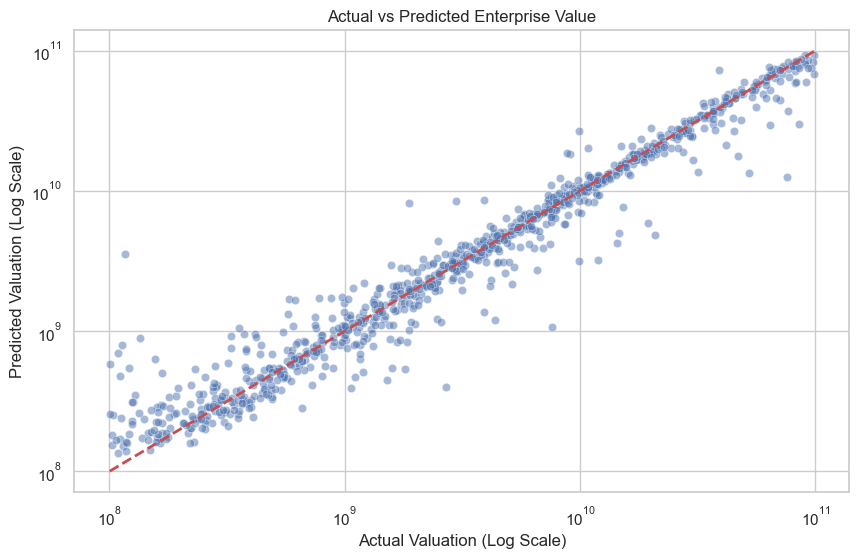

In [39]:
y_pred_df = engine.predict(X_test)
y_pred = y_pred_df["enterprise_value"]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test["enterprise_value"], y=y_pred, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'r--', lw=2)
plt.xlabel("Actual Valuation (Log Scale)")
plt.ylabel("Predicted Valuation (Log Scale)")
plt.title("Actual vs Predicted Enterprise Value")
plt.xscale('log')
plt.yscale('log')
plt.show()

/var/folders/wn/w5fg7t9n7hb773n1_40skgk80000gn/T/ipykernel_36142/2865362335.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")


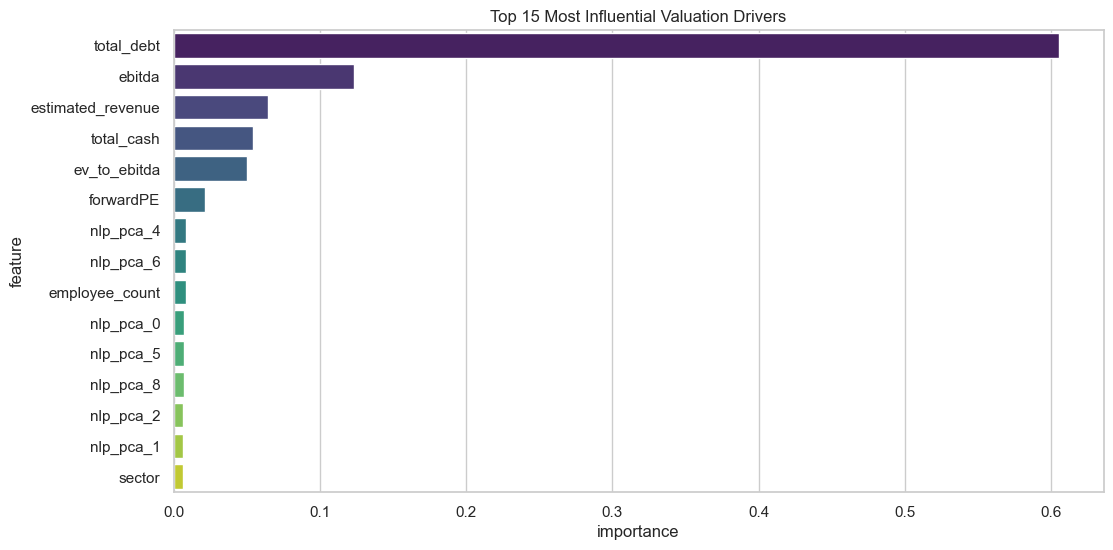

In [23]:
# Feature Importance Analysis
xgb_model = engine.pipeline.named_steps["model"].regressor_.estimators_[0]

# Reconstruct feature names from the dynamic lists
feature_names = engine.fin_cols + engine.cat_cols + [f"nlp_pca_{i}" for i in range(10)]

importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Most Influential Valuation Drivers")
plt.show()

## 5. Real-World Case Study: Valuation with Sparse Data

In this section, we simulate a real-world scenario where we only have a company's sector, estimated revenue, and its business description (NLP embeddings). We use AnaptysBio, Inc. (ANAB), a mid-sized biotechnology company, as our test case.

In [40]:
# 1. Find ANAB in the original dataset to get its index
df_raw = pd.read_parquet("../data/processed/UNIVERSAL_training.parquet")
case_study_ticker = "TXN"
ticker_row = df_raw[df_raw['ticker'] == case_study_ticker]

if not ticker_row.empty:
    idx = ticker_row.index[0]
    actual_val = ticker_row.iloc[0]['enterprise_value']
    
    # 2. Extract the corresponding row from our embedded dataset (using index)
    # We simulate sparse information by taking the full row and nulling out non-sparse financial features
    case_study_row = df.loc[[idx]].copy()
    
    # Define which columns we want to KEEP for this "sparse" valuation
    keep_cols = ['sector', 'estimated_revenue'] + [f'nlp_{i}' for i in range(384)]
    
    # Null out all other financial columns to simulate missing data
    for col in engine.fin_cols:
        if col not in keep_cols:
            case_study_row[col] = np.nan
    
    print(f"--- Case Study: {case_study_ticker} ---")
    print(f"Sector: {ticker_row.iloc[0]['sector']}")
    print(f"Actual Enterprise Value: ${actual_val:,.0f}")
    print(f"Simulated Inputs: Sector, Estimated Revenue, and Business Summary (NLP)")
    print(f"Dropped Features: {', '.join([c for c in engine.fin_cols if c not in keep_cols])}")
    
    # 3. Predict using the trained engine
    # The pipeline's KNNImputer will handle the NaNs we just introduced
    prediction_df = engine.predict(case_study_row[engine.fin_cols + engine.cat_cols + engine.nlp_cols])
    predicted_val = prediction_df.iloc[0, 0]
    
    error_pct = abs(predicted_val - actual_val) / actual_val * 100
    
    print(f"\nPredicted Enterprise Value: ${predicted_val:,.0f}")
    print(f"Valuation Variance: {error_pct:.2f}%")
    
    # Display the business summary for context
    print(f"\nBusiness Summary snippet:\n{ticker_row.iloc[0]['business_summary'][:300]}...")
else:
    print(f"Ticker {case_study_ticker} not found in dataset.")

Ticker TXN not found in dataset.
